# AutoSort Training Pipeline

Main steps:
1. Threshold detection
2. Training data preparation
3. Model training


In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface.core import concatenate_recordings
from probeinterface import write_probeinterface, read_probeinterface

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils_clique import (
    prepare_training_data_no_whiten,
    train_autosort_model,
    CliqueInfo,
    plot_cliques
)
import torch
import gc

In [2]:
channel_list_A = ['A-000', 'A-001', 'A-002',
       'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
       'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-016',
       'A-017', 'A-018', 'A-019', 'A-020', 'A-021', 'A-022', 'A-023',
       'A-024', 'A-025', 'A-026', 'A-027', 'A-028', 'A-029', 'A-030',
       'A-031', 'A-032', 'A-033', 'A-034', 'A-035', 'A-036', 'A-037',
       'A-038', 'A-039', 'A-040', 'A-041', 'A-042', 'A-043', 'A-044',
       'A-045', 'A-046', 'A-047', 'A-048', 'A-049', 'A-050', 'A-051',
       'A-052', 'A-053', 'A-054', 'A-055', 'A-056', 'A-057', 'A-058',
       'A-059', 'A-060', 'A-061', 'A-062', 'A-063', 'A-064', 'A-065',
       'A-066', 'A-067', 'A-068', 'A-069', 'A-070', 'A-071', 'A-072',
       'A-073', 'A-074', 'A-075', 'A-076', 'A-077', 'A-078', 'A-079',
       'A-080', 'A-081', 'A-082', 'A-083', 'A-084', 'A-085', 'A-086',
       'A-087', 'A-088', 'A-089', 'A-090', 'A-091', 'A-092', 'A-093',
       'A-094', 'A-095', 'A-096', 'A-097', 'A-098', 'A-099', 'A-100',
       'A-101', 'A-102', 'A-103', 'A-104', 'A-105', 'A-106', 'A-107',
       'A-108', 'A-109', 'A-110', 'A-111', 'A-112', 'A-113', 'A-114',
       'A-115', 'A-116', 'A-117', 'A-118', 'A-119', 'A-120', 'A-121',
       'A-122', 'A-123', 'A-124', 'A-125', 'A-126', 'A-127']

In [3]:
spike_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl"

recording_path = Path(f"/media/ubuntu/sda/mouse_test/raw_data/WLF_128ch2mouse1_natima_251217_225054")
rhd_files = list(recording_path.glob("*.rhd"))

file_list = sorted(rhd_files)
recording_raw_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(file, stream_id= '0'))
recording_raw = concatenate_recordings(recording_list=recording_raw_list)




In [4]:
recording_raw = recording_raw.select_channels(channel_list_A)
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [5]:
probe = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/tip_probe_128_1.json')
if probe is None:
    raise ValueError("Recording does not have probe information")

# 定义按shank构建cliques的函数
def build_shank_cliques(probe, shank_boundaries=[250, 750, 1250]):
    """
    根据x坐标划分shank并构建cliques
    
    Parameters:
        probe: Probe对象
        shank_boundaries: shank之间的x坐标边界，默认[250, 750, 1250]
                         将probe划分为4个shank:
                         - shank 0: x < 250
                         - shank 1: 250 <= x < 750
                         - shank 2: 750 <= x < 1250
                         - shank 3: x >= 1250
    
    Returns:
        cliques: List[CliqueInfo] - 每个shank对应一个clique
    """
    from typing import List
    
    df = probe.to_dataframe()
    if "device_channel_indices" in df.columns:
        device_indices = df["device_channel_indices"].astype(int).to_numpy()
    else:
        device_indices = np.arange(len(df), dtype=int)
    positions = df.loc[:, ["x", "y"]].to_numpy()
    contact_ids = df["contact_ids"].astype(str).to_numpy()
    
    # 根据x坐标划分shank
    x_coords = positions[:, 0]
    shank_boundaries_sorted = sorted(shank_boundaries)
    
    cliques: List[CliqueInfo] = []
    
    # 定义shank范围
    shank_ranges = [
        (float('-inf'), shank_boundaries_sorted[0]),  # shank 0: x < 250
        (shank_boundaries_sorted[0], shank_boundaries_sorted[1]),  # shank 1: 250 <= x < 750
        (shank_boundaries_sorted[1], shank_boundaries_sorted[2]),  # shank 2: 750 <= x < 1250
        (shank_boundaries_sorted[2], float('inf')),  # shank 3: x >= 1250
    ]
    
    for shank_id, (x_min, x_max) in enumerate(shank_ranges):
        # 找到属于当前shank的通道
        if x_min == float('-inf'):
            mask = x_coords < x_max
        elif x_max == float('inf'):
            mask = x_coords >= x_min
        else:
            mask = (x_coords >= x_min) & (x_coords < x_max)
        
        shank_device_indices = device_indices[mask]
        shank_contact_ids = contact_ids[mask]
        shank_positions = positions[mask]
        
        if len(shank_device_indices) == 0:
            print(f"[WARNING] Shank {shank_id} has no channels")
            continue
        
        # 计算shank的中心位置
        center = tuple(np.mean(shank_positions, axis=0))
        
        # 创建CliqueInfo对象
        clique = CliqueInfo(
            clique_id=shank_id,
            device_channel_indices=list(shank_device_indices),
            contact_ids=list(shank_contact_ids),
            center=center,
        )
        cliques.append(clique)
        
        print(f"[INFO] Shank {shank_id}: {len(shank_device_indices)} channels "
              f"(x range: {x_min if x_min != float('-inf') else 'min'} to "
              f"{x_max if x_max != float('inf') else 'max'})")
    
    print(f"[INFO] Built {len(cliques)} cliques from {len(shank_boundaries) + 1} shanks")
    return cliques

# Build cliques from probe by shank
cliques = build_shank_cliques(probe, shank_boundaries=[250, 750, 1250])

# Plot cliques visualization
output_dir = Path("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output")
output_dir.mkdir(parents=True, exist_ok=True)
plot_cliques(probe, cliques, output_pdf_path=str(output_dir / "cliques_visualization.pdf"))

# Save clique information for evaluation
clique_info = {
    'cliques': cliques,  # List of CliqueInfo objects
    'clique_params': {
        'method': 'shank_based',
        'shank_boundaries': [250, 750, 1250],
        'num_shanks': 4,
    },
    'probe_df': probe.to_dataframe(),  # Probe dataframe for verification
    'recording_path': recording_path,  # Recording path for reference
}

clique_info_path = output_dir / "clique_info.pkl"
with open(clique_info_path, 'wb') as f:
    pickle.dump(clique_info, f)

[INFO] Shank 0: 32 channels (x range: min to 250)
[INFO] Shank 1: 32 channels (x range: 250 to 750)
[INFO] Shank 2: 32 channels (x range: 750 to 1250)
[INFO] Shank 3: 32 channels (x range: 1250 to max)
[INFO] Built 4 cliques from 4 shanks

Clique可视化PDF已保存至: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/cliques_visualization.pdf


In [6]:

spike_inf = None
neuron_inf = None

if Path(spike_inf_path).exists():
    spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
else:
    raise ValueError(f"spike_inf not found at {spike_inf_path}")

if Path(neuron_inf_path).exists():
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
else:
    raise ValueError(f"neuron_inf.pkl not found at {neuron_inf_path}")

In [7]:
# Convert spike_inf time indices from 20k to 10k sampling rate
# Since recording has been downsampled from 20k to 10k, spike_inf time indices need to be divided by 2
if spike_inf is not None and 'time' in spike_inf.columns:
    print(f"Converting spike_inf time indices from 20k to 10k sampling rate...")
    print(f"  Original time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    spike_inf['time'] = spike_inf['time'] / 2.0
    spike_inf['time'] = spike_inf['time'].astype(int)  # Convert to integer
    print(f"  Converted time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    print(f"  Total spikes: {len(spike_inf)}")
else:
    print("Warning: spike_inf is None or does not have 'time' column")


Converting spike_inf time indices from 20k to 10k sampling rate...
  Original time range: 45 - 26619805
  Converted time range: 22 - 13309902
  Total spikes: 1256663


In [8]:
# Set parameters
from typing import Any


base_save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output"
duration_seconds = 500 

# Check if required data is loaded
if spike_inf is None:
    raise ValueError("spike_inf is required but not loaded")
if neuron_inf is None:
    raise ValueError("neuron_inf is required but not loaded")

# No-whiten detection parameters (AutoSort method)
no_whiten_params = {
    'thr_min': 2,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

all_train_data_dirs = {}


recording_channel_ids = recording_f.get_channel_ids()  
probe_df = probe.to_dataframe()
if "device_channel_indices" in probe_df.columns:
    probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
else:
    probe_device_indices = np.arange(len(probe_df), dtype=int)

device_to_recording_channel = {}
for i, device_idx in enumerate(probe_device_indices):
    if i < len(recording_channel_ids):
        device_to_recording_channel[device_idx] = recording_channel_ids[i]


for clique_id, clique in enumerate(cliques):
    save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    clique_device_indices = set(clique.device_channel_indices)
    

    sorted_device_indices = sorted(clique_device_indices)
    clique_channel_ids = [device_to_recording_channel[idx] for idx in sorted_device_indices if idx in device_to_recording_channel]
    recording_clique = recording_f.select_channels(channel_ids=clique_channel_ids)
    

    recording_clique = recording_clique.rename_channels(sorted_device_indices)
    
    clique_channels = clique_device_indices
    
    neuron_ids_in_clique = []
    for idx, row in neuron_inf.iterrows():
        channels = row.get('channel_id', [])
        if isinstance(channels, str):
            import ast
            try:
                channels = ast.literal_eval(channels)
            except:
                channels = []
        channels_set = set[Any](channels)
        if len(channels_set) > 0 and channels_set.issubset(clique_channels):
            neuron_ids_in_clique.append(row['Neuron'])
    
    neuron_inf_clique = neuron_inf[neuron_inf['Neuron'].isin(neuron_ids_in_clique)].copy()
    spike_inf_clique = spike_inf[spike_inf['neuron'].isin(neuron_ids_in_clique)].copy()
    

    train_data_dir = prepare_training_data_no_whiten(
        recording_f=recording_clique,  
        spike_inf=spike_inf_clique,
        neuron_inf=neuron_inf_clique,
        save_dir=str(save_dir),
        duration_seconds=duration_seconds,
        **no_whiten_params,
        **window_params
    )
    
    all_train_data_dirs[clique_id] = train_data_dir


### 1. Threshold Detection (No Whitening Method)
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)
Number of valid channels: 4
Valid channels list (clique channel indices): [1, 2, 28, 31]
Data shape: (5000000, 32)
Building detect_array...
Number of detected spikes: 410350

### 2. Load Ground Truth and Match
Building gt_array...
GT spike count: 29054
---spike detection rate: 0.6576
Number of matched spikes: 19107
Number of unmatched spikes: 391243

### 3. Extract Waveforms


Extracting waveforms: 100%|██████████| 30/30 [00:04<00:00,  6.39it/s]


Waveform extraction completed!
waveform shape: (410347, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/train_data
Data statistics:
  - Total spike count: 410347
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 4
  - Noise spike count: 391240
  - Valid spike count: 19107
### 1. Threshold Detection (No Whitening Method)
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)
Number of valid channels: 6
Valid cha

Extracting waveforms: 100%|██████████| 30/30 [00:07<00:00,  4.02it/s]


Waveform extraction completed!
waveform shape: (701030, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_01/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_01/train_data
Data statistics:
  - Total spike count: 701030
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 6
  - Noise spike count: 643191
  - Valid spike count: 57839
### 1. Threshold Detection (No Whitening Method)
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)
Number of valid channels: 12
Valid ch

Extracting waveforms: 100%|██████████| 30/30 [00:14<00:00,  2.02it/s]


Waveform extraction completed!
waveform shape: (1486584, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_02/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_02/train_data
Data statistics:
  - Total spike count: 1486584
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 17
  - Noise spike count: 1285112
  - Valid spike count: 201472
### 1. Threshold Detection (No Whitening Method)
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)
Number of valid channels: 11
Val

Extracting waveforms: 100%|██████████| 30/30 [00:12<00:00,  2.43it/s]


Waveform extraction completed!
waveform shape: (1235772, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/train_data
Data statistics:
  - Total spike count: 1235772
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 15
  - Noise spike count: 1128793
  - Valid spike count: 106979


## Step 2: Model Training


Checking detection of spikes for neuron: Neuron_52
Clique: 1
  Tract channel: 12
  Clique channels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(28), np.int64(29), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(49), np.int64(54), np.int64(60), np.int64(62), np.int64(63)]
  Tract channel clique index: 8

  Total spikes for this neuron: 21222
  Spikes in first 500 seconds: 7769
  Data shape: (5000000, 32)

  Threshold calculation (detect_spike_no_whiten method):
    thr_min: 2
    noise_std (tract_channel 12): 29.6516
    threshold: 59.3032

  Detection Results:
    Total spikes checked: 7769
    Detected spikes: 7612
    Detection rate: 0.9798 (97.98%)
    Total peaks detected on this channel: 115463

  Examples of detecte

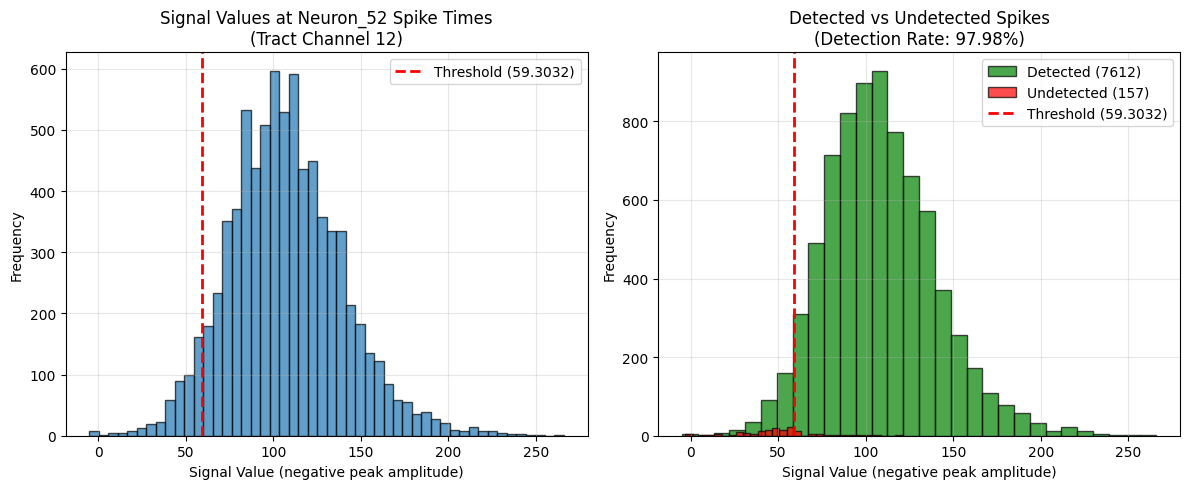

In [ ]:
# Check if spikes from a neuron can be detected on its tract_channel
# Using the same threshold logic as detect_spike_no_whiten

from utils_clique import detect_spike_no_whiten
import scipy.signal

# Select a neuron to analyze
neuron_name_to_check = "Neuron_52"  # Change this to check different neurons

# Select a clique (e.g., clique 1)
clique_id_to_check = 1

print(f"Checking detection of spikes for neuron: {neuron_name_to_check}")
print(f"Clique: {clique_id_to_check}")
print("=" * 80)

# Get the neuron info
neuron_row = neuron_inf[neuron_inf['Neuron'] == neuron_name_to_check]
if len(neuron_row) == 0:
    raise ValueError(f"Neuron {neuron_name_to_check} not found in neuron_inf")

neuron_row = neuron_row.iloc[0]
tract_channel = neuron_row['tract_channel']

# Get clique information
clique = cliques[clique_id_to_check]
clique_device_indices = set(clique.device_channel_indices)

# Check if tract_channel is in this clique
if tract_channel not in clique_device_indices:
    print(f"Warning: tract_channel {tract_channel} is not in clique {clique_id_to_check}")
    print(f"Clique channels: {sorted(clique_device_indices)}")
else:
    print(f"  Tract channel: {tract_channel}")
    print(f"  Clique channels: {sorted(clique_device_indices)}")
    
    # Get recording for this clique
    sorted_device_indices = sorted(clique_device_indices)
    recording_channel_ids = recording_f.get_channel_ids()
    probe_df = probe.to_dataframe()
    if "device_channel_indices" in probe_df.columns:
        probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
    else:
        probe_device_indices = np.arange(len(probe_df), dtype=int)
    
    device_to_recording_channel = {}
    for i, device_idx in enumerate(probe_device_indices):
        if i < len(recording_channel_ids):
            device_to_recording_channel[device_idx] = recording_channel_ids[i]
    
    clique_channel_ids = [device_to_recording_channel[idx] for idx in sorted_device_indices if idx in device_to_recording_channel]
    recording_clique = recording_f.select_channels(channel_ids=clique_channel_ids)
    recording_clique = recording_clique.rename_channels(sorted_device_indices)
    
    # Map tract_channel to clique channel index
    tract_channel_clique_idx = sorted_device_indices.index(tract_channel)
    print(f"  Tract channel clique index: {tract_channel_clique_idx}")
    
    # Get all spikes for this neuron (within a time window for analysis)
    neuron_spikes = spike_inf[spike_inf['neuron'] == neuron_name_to_check].copy()
    print(f"\n  Total spikes for this neuron: {len(neuron_spikes)}")
    
    # Use a subset of time for analysis (first duration_seconds)
    duration_seconds_check = 500
    max_frames_check = int(duration_seconds_check * recording_clique.get_sampling_frequency())
    neuron_spikes_subset = neuron_spikes[neuron_spikes['time'] < max_frames_check].copy()
    print(f"  Spikes in first {duration_seconds_check} seconds: {len(neuron_spikes_subset)}")
    
    if len(neuron_spikes_subset) > 0:
        # Load data for this clique
        trace0_car = recording_clique.get_traces(start_frame=0, end_frame=max_frames_check).astype(np.float32)
        print(f"  Data shape: {trace0_car.shape}")
        
        # Calculate threshold using the same logic as detect_spike_no_whiten
        thr_min = 2  # Same as no_whiten_params
        noise_std_detect = np.median(abs(trace0_car) / 0.6745, axis=0)
        thr = thr_min * noise_std_detect
        threshold = thr[tract_channel_clique_idx]
        print(f"\n  Threshold calculation (detect_spike_no_whiten method):")
        print(f"    thr_min: {thr_min}")
        print(f"    noise_std (tract_channel {tract_channel}): {noise_std_detect[tract_channel_clique_idx]:.4f}")
        print(f"    threshold: {threshold:.4f}")
        
        # Get signal on tract_channel
        signal = trace0_car[:, tract_channel_clique_idx]
        
        # For each spike time, check if it would be detected
        spike_times = neuron_spikes_subset['time'].values.astype(int)
        detected_count = 0
        detected_with_peak = 0
        
        # Parameters for peak detection (same as detect_spike_no_whiten)
        distance = 3
        wlen = 5
        prominence = 10
        
        # First, find all peaks that would be detected
        peaks, props = scipy.signal.find_peaks(
            -signal,  # Negative because we detect negative peaks
            height=threshold,
            distance=distance,
            wlen=wlen,
            prominence=prominence,
        )
        prominences = scipy.signal.peak_prominences(
            -signal, peaks, wlen=7
        )[0]
        peaks = peaks[props["peak_heights"] > 10]
        prominences = prominences[props["peak_heights"] > 10]
        peaks = peaks[(prominences > 15)]
        
        # Create set of detected peak times for fast lookup
        detected_peak_times = set(peaks)
        
        # Check each spike time
        detection_results = []
        for spike_time in spike_times:
            # Check if spike_time is within valid range
            if spike_time < 0 or spike_time >= len(signal):
                detection_results.append({'spike_time': spike_time, 'detected': False, 'reason': 'out_of_range'})
                continue
            
            # Check if there's a detected peak at this time or nearby (±distance samples)
            detected = False
            for offset in range(-distance, distance + 1):
                check_time = spike_time + offset
                if check_time in detected_peak_times:
                    detected = True
                    break
            
            if detected:
                detected_count += 1
                detection_results.append({'spike_time': spike_time, 'detected': True, 'reason': 'peak_detected'})
            else:
                # Check the signal value at spike_time
                signal_value = signal[spike_time]
                if -signal_value >= threshold:  # Negative peak, so check -signal_value
                    detection_results.append({'spike_time': spike_time, 'detected': False, 'reason': f'threshold_ok_but_no_peak (value: {-signal_value:.4f})'})
                else:
                    detection_results.append({'spike_time': spike_time, 'detected': False, 'reason': f'below_threshold (value: {-signal_value:.4f})'})
        
        # Statistics
        detection_rate = detected_count / len(spike_times) if len(spike_times) > 0 else 0
        print(f"\n  Detection Results:")
        print(f"    Total spikes checked: {len(spike_times)}")
        print(f"    Detected spikes: {detected_count}")
        print(f"    Detection rate: {detection_rate:.4f} ({detection_rate*100:.2f}%)")
        print(f"    Total peaks detected on this channel: {len(detected_peak_times)}")
        
        # Show some examples of detected and undetected spikes
        print(f"\n  Examples of detected spikes (first 10):")
        detected_examples = [r for r in detection_results if r['detected']][:10]
        for i, res in enumerate(detected_examples):
            print(f"    {i+1}. Time: {res['spike_time']}, Signal value: {-signal[res['spike_time']]:.4f}")
        
        if len(detected_examples) < len(spike_times):
            print(f"\n  Examples of undetected spikes (first 10):")
            undetected_examples = [r for r in detection_results if not r['detected']][:10]
            for i, res in enumerate(undetected_examples):
                signal_val = -signal[res['spike_time']]
                print(f"    {i+1}. Time: {res['spike_time']}, Signal value: {signal_val:.4f}, Threshold: {threshold:.4f}, Reason: {res['reason']}")
        
        # Plot histogram of signal values at spike times
        signal_values_at_spikes = [-signal[t] for t in spike_times if 0 <= t < len(signal)]
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(signal_values_at_spikes, bins=50, alpha=0.7, edgecolor='black')
        plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
        plt.xlabel('Signal Value (negative peak amplitude)')
        plt.ylabel('Frequency')
        plt.title(f'Signal Values at {neuron_name_to_check} Spike Times\n(Tract Channel {tract_channel})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot detected vs undetected
        detected_values = [-signal[r['spike_time']] for r in detection_results if r['detected'] and 0 <= r['spike_time'] < len(signal)]
        undetected_values = [-signal[r['spike_time']] for r in detection_results if not r['detected'] and 0 <= r['spike_time'] < len(signal)]
        
        plt.subplot(1, 2, 2)
        if len(detected_values) > 0:
            plt.hist(detected_values, bins=30, alpha=0.7, label=f'Detected ({len(detected_values)})', color='green', edgecolor='black')
        if len(undetected_values) > 0:
            plt.hist(undetected_values, bins=30, alpha=0.7, label=f'Undetected ({len(undetected_values)})', color='red', edgecolor='black')
        plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
        plt.xlabel('Signal Value (negative peak amplitude)')
        plt.ylabel('Frequency')
        plt.title(f'Detected vs Undetected Spikes\n(Detection Rate: {detection_rate*100:.2f}%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    else:
        print(f"  No spikes found for this neuron in the first {duration_seconds_check} seconds")


In [10]:
# Set training parameters
training_params = {
    'epochs': 20,
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
    'early_stopping': True,  # Enable early stopping
    'patience': 5,  # Stop if accuracy doesn't improve for 5 consecutive epochs
    'min_delta': 0.0,  # Minimum change
}

# Repeat training 5 times per clique
n_runs = 1

# Train models for each clique
all_models_dict = {}
all_logs_dict = {}

for clique_id, clique in enumerate(cliques):
    if clique_id not in all_train_data_dirs:
        print(f"Skipping clique {clique_id} (no training data)")
        continue
    
    print(f"\n{'='*80}")
    print(f"Training models for Clique {clique_id:02d}")
    print(f"{'='*80}")
    
    train_data_dir = all_train_data_dirs[clique_id]
    base_model_save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "model_save"
    
    # Get number of channels for this clique
    n_channels = len(clique.device_channel_indices)
    
    all_models = []
    all_logs = []
    
    for run_id in range(1, n_runs + 1):
        print(f"\n{'-'*60}")
        print(f"Clique {clique_id:02d} - Training run {run_id}/{n_runs}")
        print(f"{'-'*60}")
        
        # Create independent save directory for each training run
        model_save_dir = base_model_save_dir / f"run_{run_id}"
        model_save_dir.mkdir(parents=True, exist_ok=True)
        
        # Train model
        autosort_model, training_log = train_autosort_model(
            train_data_dir=train_data_dir,
            model_save_dir=str(model_save_dir),
            n_channels=n_channels,
            **training_params
        )
        
        all_models.append(autosort_model)
        all_logs.append(training_log)
        
        print(f"Clique {clique_id:02d} - Run {run_id} completed!")
        print(f"Model save directory: {model_save_dir}")
    
    all_models_dict[clique_id] = all_models
    all_logs_dict[clique_id] = all_logs
    gc.collect()
    torch.cuda.empty_cache()
    print(f"\nClique {clique_id:02d} - All {n_runs} training runs completed!")

print(f"\n{'='*80}")
print(f"All cliques training completed!")
print(f"{'='*80}")



Training models for Clique 00

------------------------------------------------------------
Clique 00 - Training run 1/1
------------------------------------------------------------
Using device: cuda
Create dataset...
Model parameters:
  - Number of channels: 32
  - Window length: 30
  - Number of units: 4
  - Input dimension: 990
Unit ID list saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/model_save/run_1/keep_id.pkl
Saved train/val split indices to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/model_save/run_1/train_val_split_indices.pkl

Dataset split:
  - Training set: 328277 samples
  - Validation set: 82070 samples

Starting training (total 20 epochs)...
Early stopping enabled: patience=5, min_delta=0.0
epoch : 1/20


Training: 100%|██████████| 642/642 [00:05<00:00, 126.71it/s]


epoch : 1/20, detection loss = 422.469304, classification loss = 580.839002


Validation: 100%|██████████| 161/161 [00:00<00:00, 222.21it/s]


epoch : 1/20, val detection loss = 328.696630, classification loss = 385.143177
Validation Loss Decreased(inf--->713.839807)
Validation Accuracy Decreased(inf--->0.843024) 	 Saving The Model (Best Acc Epoch)
epoch : 2/20


...

epoch : 5/20, val detection loss = 266.865441, classification loss = 154.469606
Validation Loss Decreased(430.690363--->421.335047)
epoch : 6/20


Training: 100%|██████████| 1931/1931 [00:14<00:00, 132.10it/s]


epoch : 6/20, detection loss = 184.339871, classification loss = 118.382317


Validation: 100%|██████████| 483/483 [00:02<00:00, 218.05it/s]


epoch : 6/20, val detection loss = 273.992860, classification loss = 144.105332
Validation Loss Decreased(421.335047--->418.098192)

Early stopping triggered: 5 consecutive epochs without improvement
Best accuracy: 0.856649 (Epoch 1)

Saving final model (epoch 20) for evaluation...

Training completed! Training log saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/model_save/run_1/training_log.csv
Best validation accuracy: 0.856649 (Epoch 1)
Clique 03 - Run 1 completed!
Model save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/model_save/run_1

Clique 03 - All 1 training runs completed!

All cliques training completed!


Loading model from: output/clique_03/model_save/run_1
Loading data from: output/clique_03/train_data
Validation set size: 247155
Model loaded successfully

Extracting embeddings...
Detection embeddings shape: (247155, 30)
Classification embeddings shape: (247155, 30)

Applying UMAP...
UMAP transformation completed

Plotting detection model embeddings...
Figure saved to: output/clique_03/model_save/run_1/umap_detection.png


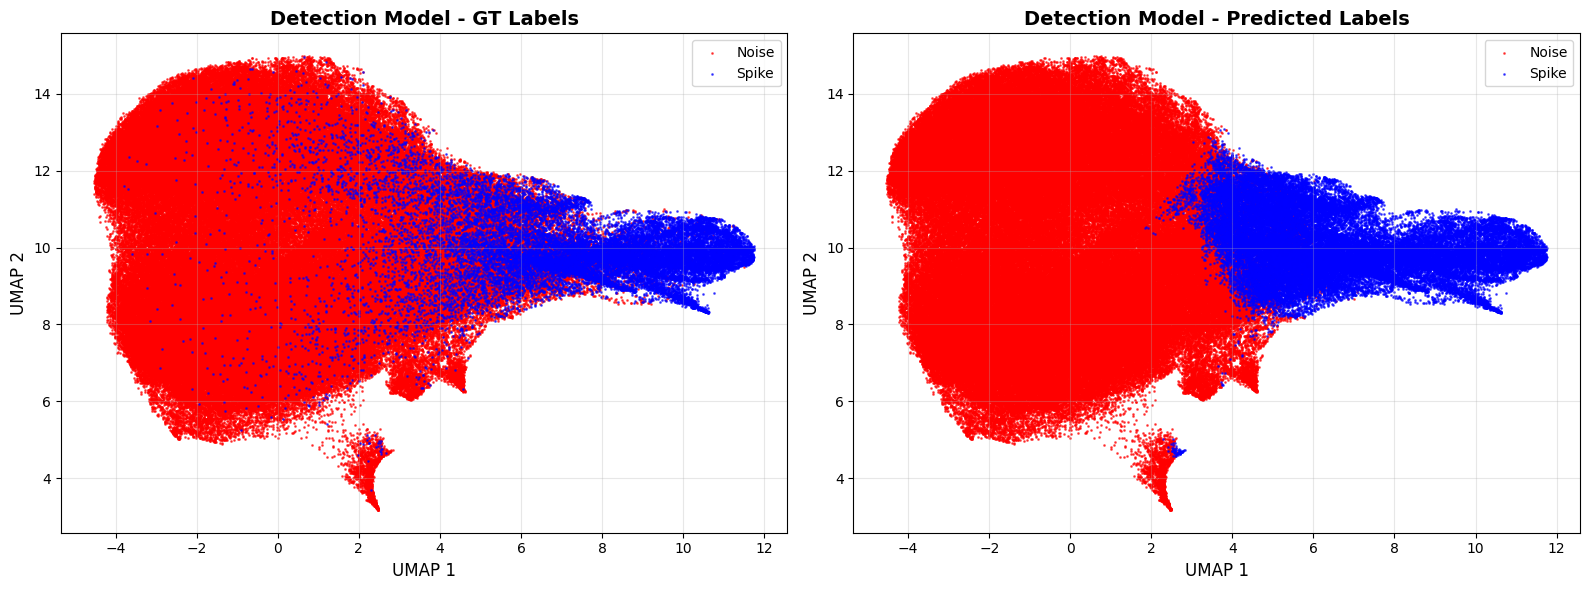


Plotting classification model embeddings...
Figure saved to: output/clique_03/model_save/run_1/umap_classification.png


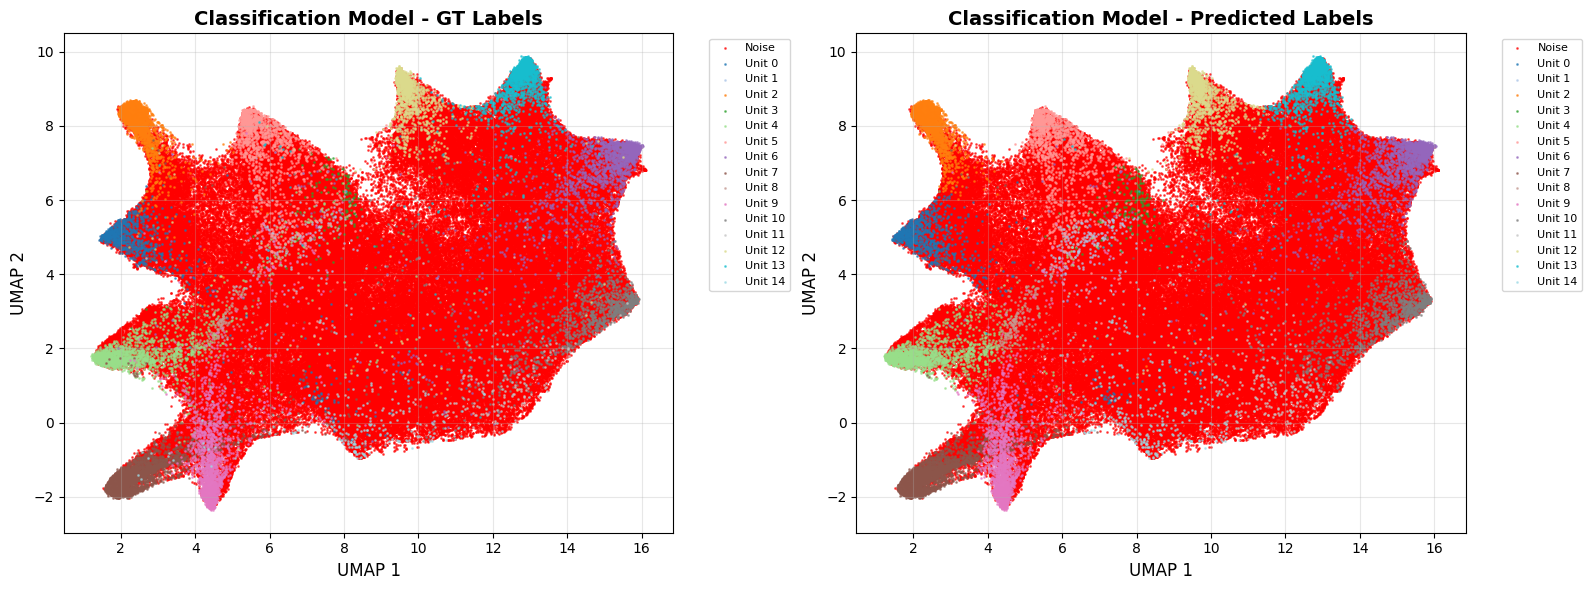


Visualization completed!


In [11]:
# Extract way4 embeddings from detection and classification models and visualize with UMAP

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from umap import UMAP
from sklearn.preprocessing import LabelEncoder
from utils_clique import SimpleAutoSort, SimpleWaveformLoader

# Parameters
clique_id =3
run_id = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
base_save_dir = Path("output")
model_save_dir = base_save_dir / f"clique_{clique_id:02d}" / "model_save" / f"run_{run_id}"
train_data_dir = base_save_dir / f"clique_{clique_id:02d}" / "train_data"

print(f"Loading model from: {model_save_dir}")
print(f"Loading data from: {train_data_dir}")

# Load dataset
dataset = SimpleWaveformLoader(root=str(train_data_dir) + "/", shank_channel=None)
n_channels = dataset.Img.shape[1]
samplepoints = dataset.Img.shape[2]

# Load train/val split indices
train_val_split_path = model_save_dir / "train_val_split_indices.pkl"
if train_val_split_path.exists():
    with open(train_val_split_path, "rb") as f:
        train_indices, val_indices = pickle.load(f)
    val_dataset = torch.utils.data.Subset(dataset, val_indices)
    print(f"Validation set size: {len(val_indices)}")
else:
    raise FileNotFoundError(f"Train/val split indices not found at {train_val_split_path}")

# Create model
autosort_model = SimpleAutoSort(
    ch_num=n_channels,
    samplepoints=samplepoints,
    device=device,
    set_shank_id=dataset.keep_id,
    save_dir=str(model_save_dir),
    pos_weight_noise=dataset.pos_weight_noise.to(device),
    pos_weight_label=dataset.pos_weight_label.to(device)
)

# Load model weights
autosort_model.load_model()
autosort_model.eval()
print("Model loaded successfully")

# Create data loader
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1024, shuffle=False, drop_last=False)

# Extract embeddings and labels
print("\nExtracting embeddings...")
detection_embeddings = []
classification_embeddings = []
gt_noise_labels = []
pred_noise_labels = []
gt_unit_labels = []
pred_unit_labels = []

with torch.no_grad():
    for batch_idx, (batch_features, classify_labels, labels, single_waveform) in enumerate(val_loader):
        batch_features = batch_features.reshape(batch_features.shape[0], -1).to(device)
        single_waveform = single_waveform.to(device)
        labels = labels.to(device)
        classify_labels = classify_labels.to(device)
        
        # Concatenate features (waveform + single)
        codes = torch.cat((batch_features, single_waveform), axis=1)
        
        # Extract way4 embeddings from detection model (clsfier_noise)
        detection_emb = autosort_model.clsfier_noise.intermediate_forward(codes.float())
        detection_embeddings.append(detection_emb.detach().cpu().numpy())
        
        # Extract way4 embeddings from classification model (clsfier_label)
        classification_emb = autosort_model.clsfier_label.intermediate_forward(codes.float())
        classification_embeddings.append(classification_emb.detach().cpu().numpy())
        
        # Get predictions
        noise_output = autosort_model.clsfier_noise(codes.float())
        pred_noise = torch.argmax(noise_output, dim=1)
        gt_noise = torch.argmax(labels, dim=1)
        
        gt_noise_labels.append(gt_noise.detach().cpu().numpy())
        pred_noise_labels.append(pred_noise.detach().cpu().numpy())
        
        # Unit labels (only for non-noise samples)
        test = labels[:, 1] == 1
        if sum(test) > 0:
            unit_output = autosort_model.clsfier_label(codes.float()[test, :])
            pred_unit = torch.argmax(unit_output, dim=1)
            gt_unit = torch.argmax(classify_labels[test, :len(autosort_model.set_shank_id)], dim=1)
            
            # Create full arrays (with -1 for noise samples)
            full_pred_unit = np.full(len(test), -1, dtype=int)
            full_gt_unit = np.full(len(test), -1, dtype=int)
            full_pred_unit[test.cpu().numpy()] = pred_unit.cpu().numpy()
            full_gt_unit[test.cpu().numpy()] = gt_unit.cpu().numpy()
            
            pred_unit_labels.append(full_pred_unit)
            gt_unit_labels.append(full_gt_unit)
        else:
            pred_unit_labels.append(np.full(len(test), -1, dtype=int))
            gt_unit_labels.append(np.full(len(test), -1, dtype=int))

# Concatenate all embeddings and labels
detection_embeddings = np.concatenate(detection_embeddings, axis=0)
classification_embeddings = np.concatenate(classification_embeddings, axis=0)
gt_noise_labels = np.concatenate(gt_noise_labels, axis=0)
pred_noise_labels = np.concatenate(pred_noise_labels, axis=0)
gt_unit_labels = np.concatenate(gt_unit_labels, axis=0)
pred_unit_labels = np.concatenate(pred_unit_labels, axis=0)

print(f"Detection embeddings shape: {detection_embeddings.shape}")
print(f"Classification embeddings shape: {classification_embeddings.shape}")

# Apply UMAP
print("\nApplying UMAP...")
umap_detection = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_classification = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)

detection_2d = umap_detection.fit_transform(detection_embeddings)
classification_2d = umap_classification.fit_transform(classification_embeddings)

print("UMAP transformation completed")

# Create label mappings for visualization
# For noise detection: 0=noise, 1=spike
# For unit classification: use unit IDs, -1 for noise

# Plot function
def plot_umap(embeddings_2d, gt_labels, pred_labels, title, label_type="noise", save_path=None):
    """Plot UMAP visualization with labels"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    if label_type == "noise":
        # Noise detection labels: 0=noise, 1=spike
        unique_labels = np.unique(gt_labels)
        colors = ['red', 'blue']
        label_names = ['Noise', 'Spike']
        
        for i, label in enumerate(unique_labels):
            mask = gt_labels == label
            axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                          c=colors[label], alpha=0.6, s=1, label=label_names[label])
        
        axes[0].set_title(f'{title} - GT Labels', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('UMAP 1', fontsize=12)
        axes[0].set_ylabel('UMAP 2', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Predicted labels
        unique_labels_pred = np.unique(pred_labels)
        for i, label in enumerate(unique_labels_pred):
            mask = pred_labels == label
            axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                          c=colors[label], alpha=0.6, s=1, label=label_names[label])
        
        axes[1].set_title(f'{title} - Predicted Labels', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('UMAP 1', fontsize=12)
        axes[1].set_ylabel('UMAP 2', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
    else:  # unit classification
        # Unit labels: -1 for noise, unit IDs for spikes
        # GT labels
        noise_mask = gt_labels == -1
        spike_mask = ~noise_mask
        
        axes[0].scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1], 
                       c='red', alpha=0.6, s=1, label='Noise')
        
        # Use different colors for different units
        unique_units = np.unique(gt_labels[spike_mask])
        if len(unique_units) > 0:
            cmap = plt.cm.get_cmap('tab20', len(unique_units))
            for i, unit in enumerate(unique_units):
                unit_mask = (gt_labels == unit) & spike_mask
                if np.sum(unit_mask) > 0:
                    axes[0].scatter(embeddings_2d[unit_mask, 0], embeddings_2d[unit_mask, 1], 
                                  c=[cmap(i)], alpha=0.6, s=1, label=f'Unit {unit}')
        
        axes[0].set_title(f'{title} - GT Labels', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('UMAP 1', fontsize=12)
        axes[0].set_ylabel('UMAP 2', fontsize=12)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axes[0].grid(True, alpha=0.3)
        
        # Predicted labels
        noise_mask_pred = pred_labels == -1
        spike_mask_pred = ~noise_mask_pred
        
        axes[1].scatter(embeddings_2d[noise_mask_pred, 0], embeddings_2d[noise_mask_pred, 1], 
                       c='red', alpha=0.6, s=1, label='Noise')
        
        unique_units_pred = np.unique(pred_labels[spike_mask_pred])
        if len(unique_units_pred) > 0:
            cmap = plt.cm.get_cmap('tab20', max(len(unique_units_pred), 1))
            for i, unit in enumerate(unique_units_pred):
                unit_mask = (pred_labels == unit) & spike_mask_pred
                if np.sum(unit_mask) > 0:
                    axes[1].scatter(embeddings_2d[unit_mask, 0], embeddings_2d[unit_mask, 1], 
                                  c=[cmap(i % len(unique_units_pred))], alpha=0.6, s=1, label=f'Unit {unit}')
        
        axes[1].set_title(f'{title} - Predicted Labels', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('UMAP 1', fontsize=12)
        axes[1].set_ylabel('UMAP 2', fontsize=12)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.show()

# Plot detection model embeddings
print("\nPlotting detection model embeddings...")
plot_umap(detection_2d, gt_noise_labels, pred_noise_labels, "Detection Model", label_type="noise",
          save_path=model_save_dir / "umap_detection.png")

# Plot classification model embeddings
print("\nPlotting classification model embeddings...")
plot_umap(classification_2d, gt_unit_labels, pred_unit_labels, "Classification Model", label_type="unit",
          save_path=model_save_dir / "umap_classification.png")

print("\nVisualization completed!")


In [12]:
# 计算 spike 的 position waveform 和 neuron 的 position waveform 之间的相关性

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 参数设置
left_sample = 10  # 波形窗口左侧采样点数
right_sample = 20  # 波形窗口右侧采样点数
window_size = left_sample + right_sample  # 总窗口大小
max_spikes_per_neuron = 1000  # 每个 neuron 最多分析的 spike 数量（用于加速）

print("=" * 80)
print("计算 spike position waveform 和 neuron position waveform 的相关性")
print("=" * 80)

# 检查数据是否已加载
if spike_inf is None or neuron_inf is None:
    raise ValueError("spike_inf 和 neuron_inf 必须已加载")

# 获取 probe 信息
probe_df = probe.to_dataframe()
if "device_channel_indices" in probe_df.columns:
    probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
else:
    probe_device_indices = np.arange(len(probe_df), dtype=int)

# 获取通道位置信息
channel_positions = {}
for idx, device_idx in enumerate(probe_device_indices):
    if idx < len(probe_df):
        row = probe_df.iloc[idx]
        channel_positions[device_idx] = (row['x'], row['y'])

# 获取 recording 的通道映射
recording_channel_ids = recording_f.get_channel_ids()
device_to_recording_channel = {}
for i, device_idx in enumerate(probe_device_indices):
    if i < len(recording_channel_ids):
        device_to_recording_channel[device_idx] = recording_channel_ids[i]

# 获取所有 neuron 的 tract_channel 信息
neuron_tract_channels = {}
for idx, row in neuron_inf.iterrows():
    neuron_id = row['Neuron']
    if 'tract_channel' in row and pd.notna(row['tract_channel']):
        neuron_tract_channels[neuron_id] = int(row['tract_channel'])
    elif 'channel_id' in row:
        channel_id = row['channel_id']
        if isinstance(channel_id, str):
            import ast
            try:
                channel_id = ast.literal_eval(channel_id)
            except:
                channel_id = []
        if isinstance(channel_id, (list, tuple, np.ndarray)) and len(channel_id) > 0:
            neuron_tract_channels[neuron_id] = int(channel_id[0])
        else:
            neuron_tract_channels[neuron_id] = None
    else:
        neuron_tract_channels[neuron_id] = None

print(f"\n找到 {len(neuron_tract_channels)} 个 neuron")
print(f"其中 {sum(1 for v in neuron_tract_channels.values() if v is not None)} 个有 tract_channel 信息")

# 获取所有有 tract_channel 的 neuron
valid_neurons = [nid for nid, ch in neuron_tract_channels.items() if ch is not None]
print(f"将分析 {len(valid_neurons)} 个有效 neuron")

# 存储结果
correlation_results = []

# 获取 recording 数据（只加载一次，避免重复加载）
print("\n加载 recording 数据...")
max_time = spike_inf['time'].max() + right_sample + 1
if max_time > recording_f.get_num_samples():
    max_time = recording_f.get_num_samples()
    
traces = recording_f.get_traces(start_frame=0, end_frame=max_time).astype(np.float32)
print(f"Recording 数据形状: {traces.shape} (时间点, 通道数)")

# 对每个 neuron 进行分析
for neuron_id in tqdm(valid_neurons, desc="处理 neuron"):
    tract_channel = neuron_tract_channels[neuron_id]
    
    # 检查 tract_channel 是否在 recording 中
    if tract_channel not in device_to_recording_channel:
        continue
    
    tract_channel_recording_idx = recording_channel_ids.index(device_to_recording_channel[tract_channel])
    
    # 获取该 neuron 的所有 spike
    neuron_spikes = spike_inf[spike_inf['neuron'] == neuron_id].copy()
    
    # 限制分析的 spike 数量以加速
    if len(neuron_spikes) > max_spikes_per_neuron:
        neuron_spikes = neuron_spikes.sample(n=max_spikes_per_neuron, random_state=42)
    
    if len(neuron_spikes) == 0:
        continue
    
    # 过滤掉边界附近的 spike
    spike_times = neuron_spikes['time'].values.astype(int)
    valid_mask = (spike_times >= left_sample) & (spike_times < traces.shape[0] - right_sample)
    spike_times = spike_times[valid_mask]
    neuron_spikes = neuron_spikes.iloc[valid_mask]
    
    if len(spike_times) == 0:
        continue
    
    # 提取波形
    waveforms_detection = []  # 在检测位置（最大振幅通道）的波形
    waveforms_neuron = []  # 在 neuron tract_channel 位置的波形
    detection_channel_indices = []  # 存储每个 spike 的检测通道索引
    
    for spike_time in spike_times:
        # 提取完整波形窗口 (所有通道)
        waveform_window = traces[spike_time - left_sample:spike_time + right_sample, :]  # (window_size, n_channels)
        
        # 找到最大振幅的通道（检测位置）
        # 计算每个通道的峰值到峰值振幅
        channel_amplitudes = np.max(waveform_window, axis=0) - np.min(waveform_window, axis=0)
        detection_channel_idx = np.argmax(channel_amplitudes)
        
        # 提取检测位置的波形（单通道）
        waveform_detection = waveform_window[:, detection_channel_idx]
        
        # 提取 neuron tract_channel 位置的波形（单通道）
        waveform_neuron = waveform_window[:, tract_channel_recording_idx]
        
        waveforms_detection.append(waveform_detection)
        waveforms_neuron.append(waveform_neuron)
        detection_channel_indices.append(detection_channel_idx)
    
    waveforms_detection = np.array(waveforms_detection)  # (n_spikes, window_size)
    waveforms_neuron = np.array(waveforms_neuron)  # (n_spikes, window_size)
    
    # 计算每个 spike 的相关性
    for i in range(len(waveforms_detection)):
        wf_det = waveforms_detection[i]
        wf_neu = waveforms_neuron[i]
        
        # 计算 Pearson 相关系数
        if np.std(wf_det) > 0 and np.std(wf_neu) > 0:
            corr, p_value = pearsonr(wf_det, wf_neu)
        else:
            corr, p_value = np.nan, np.nan
        
        correlation_results.append({
            'neuron': neuron_id,
            'tract_channel': tract_channel,
            'detection_channel': recording_channel_ids[detection_channel_indices[i]],
            'correlation': corr,
            'p_value': p_value,
            'spike_time': spike_times[i]
        })

# 转换为 DataFrame
corr_df = pd.DataFrame(correlation_results)

print(f"\n分析完成！共分析了 {len(corr_df)} 个 spike")
print(f"有效相关性数量: {corr_df['correlation'].notna().sum()}")

# 统计信息
if len(corr_df) > 0:
    print("\n相关性统计:")
    print(f"  平均相关性: {corr_df['correlation'].mean():.4f}")
    print(f"  中位数相关性: {corr_df['correlation'].median():.4f}")
    print(f"  标准差: {corr_df['correlation'].std():.4f}")
    print(f"  最小值: {corr_df['correlation'].min():.4f}")
    print(f"  最大值: {corr_df['correlation'].max():.4f}")
    
    # 按 neuron 统计
    print("\n按 neuron 统计相关性:")
    neuron_stats = corr_df.groupby('neuron')['correlation'].agg(['mean', 'std', 'count'])
    print(neuron_stats.head(10))
    
    # 可视化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. 相关性分布直方图
    axes[0, 0].hist(corr_df['correlation'].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(corr_df['correlation'].mean(), color='r', linestyle='--', 
                       label=f'均值: {corr_df["correlation"].mean():.4f}')
    axes[0, 0].set_xlabel('相关系数')
    axes[0, 0].set_ylabel('频数')
    axes[0, 0].set_title('Spike Position Waveform 和 Neuron Position Waveform 相关性分布')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 按 neuron 的平均相关性
    neuron_mean_corr = corr_df.groupby('neuron')['correlation'].mean().sort_values()
    axes[0, 1].barh(range(len(neuron_mean_corr)), neuron_mean_corr.values)
    axes[0, 1].set_yticks(range(len(neuron_mean_corr)))
    axes[0, 1].set_yticklabels(neuron_mean_corr.index, fontsize=8)
    axes[0, 1].set_xlabel('平均相关系数')
    axes[0, 1].set_title('各 Neuron 的平均相关性')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. 相关性箱线图（按 neuron）
    if len(neuron_mean_corr) > 0:
        top_neurons = neuron_mean_corr.head(10).index
        corr_subset = corr_df[corr_df['neuron'].isin(top_neurons)]
        if len(corr_subset) > 0:
            corr_subset.boxplot(column='correlation', by='neuron', ax=axes[1, 0])
            axes[1, 0].set_title('Top 10 Neuron 的相关性分布')
            axes[1, 0].set_xlabel('Neuron')
            axes[1, 0].set_ylabel('相关系数')
            plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 4. 相关性 vs P-value 散点图
    valid_corr = corr_df[corr_df['correlation'].notna() & corr_df['p_value'].notna()]
    if len(valid_corr) > 0:
        axes[1, 1].scatter(valid_corr['p_value'], valid_corr['correlation'], 
                          alpha=0.5, s=10)
        axes[1, 1].axhline(0, color='r', linestyle='--', alpha=0.5)
        axes[1, 1].set_xlabel('P-value')
        axes[1, 1].set_ylabel('相关系数')
        axes[1, 1].set_title('相关性 vs P-value')
        axes[1, 1].set_xscale('log')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 保存结果
    output_dir = Path(base_save_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    result_path = output_dir / "spike_neuron_waveform_correlation.csv"
    # corr_df.to_csv(result_path, index=False)
    print(f"\n结果已保存至: {result_path}")
else:
    print("\n没有找到有效的数据进行分析")


计算 spike position waveform 和 neuron position waveform 的相关性

找到 42 个 neuron
其中 42 个有 tract_channel 信息
将分析 42 个有效 neuron

加载 recording 数据...
Recording 数据形状: (13309923, 128) (时间点, 通道数)


处理 neuron:   0%|          | 0/42 [00:00<?, ?it/s]


AttributeError: 'numpy.ndarray' object has no attribute 'index'